In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import ttest_ind

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import src.config

# ── Run identity ──────────────────────────────────────────────────────────────
# Set RUN_ID to the timestamp of the run you want to evaluate.
# Leave empty ("") to use the most recent results file in the phase folder.
RUN_ID = ""

PHASE          = src.config.PHASE_SETTINGS["phase"]   # "train" or "test"
TOP_N          = src.config.PHASE_SETTINGS["top_n"]
N_BUCKETS      = 30
ROLLING_SHARPE_WINDOW = 30

In [ ]:
from pathlib import Path

def _resolve_results_path(run_id: str, phase: str) -> Path:
    pred_dir = Path("..") / "data" / "predictions" / phase
    if run_id:
        return pred_dir / f"predictions_{run_id}.csv"
    candidates = sorted(pred_dir.glob("predictions_*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No predictions files found in {pred_dir}")
    return candidates[-1]

def _resolve_feature_importance_path(run_id: str, phase: str) -> Path:
    pred_dir = Path("..") / "data" / "predictions" / phase
    if run_id:
        return pred_dir / f"feature_importance_{run_id}.csv"
    candidates = sorted(pred_dir.glob("feature_importance_*.csv"))
    if not candidates:
        return None
    return candidates[-1]

def load_data(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date']).dt.to_period("Q").dt.start_time
    df['label'] = np.exp(df['label'])
    df = df.sort_values('date')
    return df

_results_path = _resolve_results_path(RUN_ID, PHASE)
print(f"Loading: {_results_path}")
df = load_data(_results_path)

_fi_path = _resolve_feature_importance_path(RUN_ID, PHASE)
fi_df = pd.read_csv(_fi_path) if _fi_path and Path(_fi_path).exists() else None
if fi_df is not None:
    fi_df["period_date"] = pd.to_datetime(fi_df["period_date"])
    print(f"Feature importance loaded: {len(fi_df):,} rows from {_fi_path.name}")
else:
    print("Feature importance file not found — items 7 & 9 charts will be skipped.")

In [46]:
def build_quarterly_portfolios(df):

    portfolios = []

    for q, group in df.groupby('date'):

        group = group.sort_values('pred')

        short_leg = group.head(TOP_N)
        long_leg = group.tail(TOP_N)

        long_return = long_leg['label'].mean()
        short_return = short_leg['label'].mean()

        portfolios.append({
            "date": group['date'].max(),
            "long_return": long_return,
            "short_return": short_return,
            "long_short_return": (long_return + short_return)/2
        })

    port = pd.DataFrame(portfolios).sort_values("date")

    return port


def build_benchmark(df):
        
    bench = (
        df.groupby("date")["label"]
        .mean()
        .reset_index()
        .rename(columns={"label": "benchmark_return"})
    )

    return bench

port = build_quarterly_portfolios(df)
bench = build_benchmark(df)

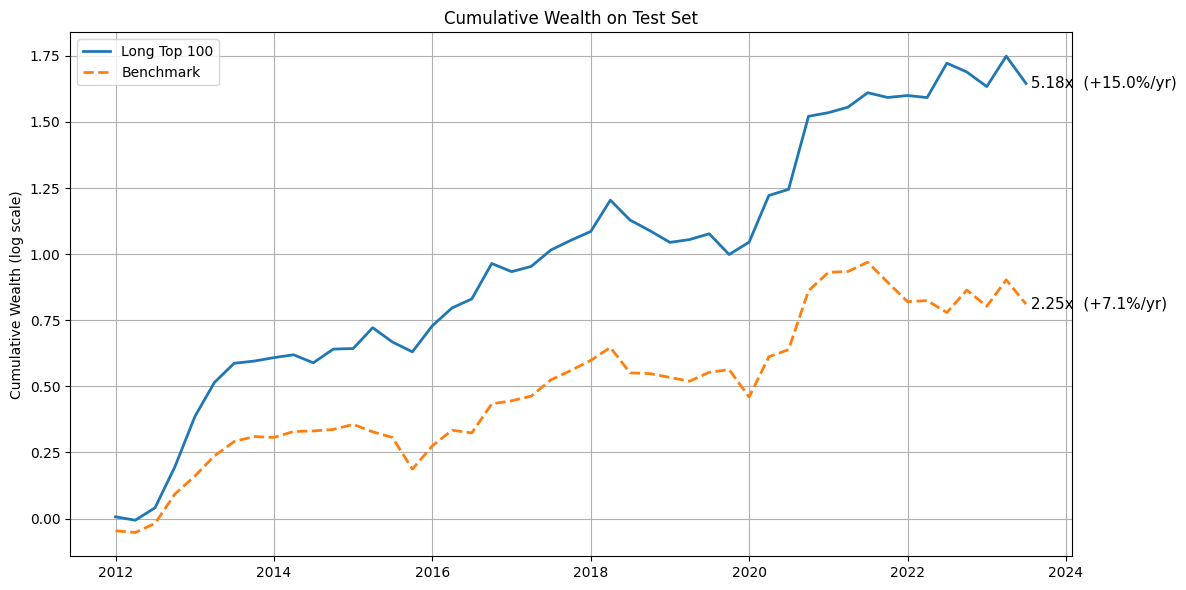

In [47]:
def cumulative_wealth(returns):

    return (returns).cumprod()


def plot_cumulative(port, benchmark):

    merged = pd.merge(port, benchmark, on="date", how="left")

    merged["Long Strategy"] = cumulative_wealth(merged["long_return"])
    merged["Short Strategy"] = cumulative_wealth(merged["short_return"])
    merged["Long-Short Strategy"] = cumulative_wealth(merged["long_short_return"])
    merged["wealth_benchmark"] = cumulative_wealth(merged["benchmark_return"])

    n = len(merged)

    series = [
        (merged["date"], merged["Long Strategy"],       f"Long Top {TOP_N}",              "-",  None),
        # (merged["date"], merged["Short Strategy"],      f"Short Worst {TOP_N}",             "-",  None),
        # (merged["date"], merged["Long-Short Strategy"], f"Long+Short Top/Worst {TOP_N}",  "-",  None),
        (merged["date"], merged["wealth_benchmark"],    "Benchmark",                               "--", None),
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    for x, y, label, ls, _ in series:
        ax.plot(x, np.log(y), label=label, linewidth=2, linestyle=ls)

        final_val = y.iloc[-1]
        annual_geomean = final_val ** (4 / n) - 1

        ax.annotate(
            f" {final_val:.2f}x  ({annual_geomean*100:+.1f}%/yr)",
            xy=(x.iloc[-1], np.log(final_val)),
            fontsize=11,
            va="center",
        )

    ax.set_ylabel("Cumulative Wealth (log scale)")
    if TRAIN_OR_TEST == "train":
        ax.set_title("Cumulative Wealth on Training Set")
    else:
        ax.set_title("Cumulative Wealth on Test Set")
    ax.legend()

    plt.tight_layout()
    plt.grid()
    plt.show()

plot_cumulative(port, bench)

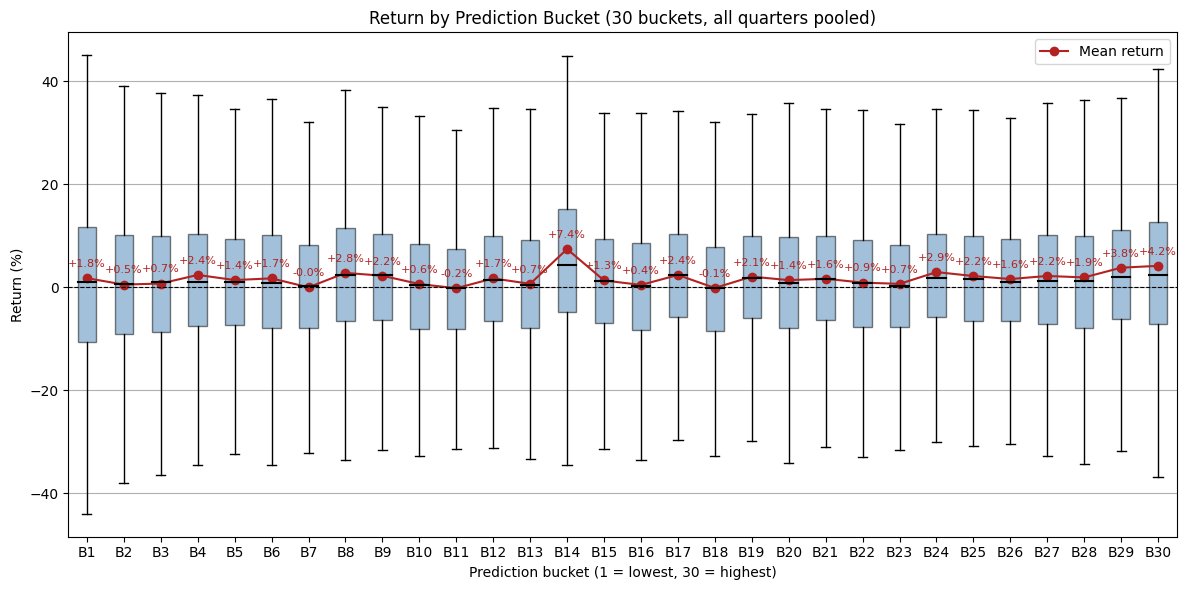

Top bucket vs Universe:T-statistic: 7.3842, P-value: 0.0000
Top bucket vs Lowest bucket:T-statistic: 3.9116, P-value: 0.0000
Upper half vs Lower half:T-statistic: 1.6169, P-value: 0.0530


In [48]:
N_BUCKETS = 30

def plot_prediction_buckets(df, n_buckets=N_BUCKETS):

    d = df.copy()

    # Within each quarter assign a rank percentile, then cut into equal-width buckets
    d["rank_pct"] = d.groupby("date")["pred"].rank(pct=True)
    d["bucket"] = pd.cut(
        d["rank_pct"],
        bins=n_buckets,
        labels=range(1, n_buckets + 1),
    )

    # Convert gross-return multipliers to simple % returns
    d["return_pct"] = (d["label"] - 1) * 100

    bucket_data   = [d.loc[d["bucket"] == b, "return_pct"].dropna().values for b in range(1, n_buckets + 1)]
    bucket_means  = [arr.mean() for arr in bucket_data]
    bucket_labels = [f"B{b}" for b in range(1, n_buckets + 1)]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        bucket_data,
        labels=bucket_labels,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
        medianprops=dict(color="black", linewidth=1.5),
    )

    # Mean return line
    ax.plot(range(1, n_buckets + 1), bucket_means, color="firebrick",
            marker="o", linewidth=1.5, label="Mean return")

    # Annotate mean on each bucket
    for i, mean in enumerate(bucket_means, start=1):
        ax.annotate(
            f"{mean:+.1f}%",
            xy=(i, mean),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="firebrick",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_xlabel(f"Prediction bucket (1 = lowest, {n_buckets} = highest)")
    ax.set_ylabel("Return (%)")
    ax.set_title(f"Return by Prediction Bucket ({n_buckets} buckets, all quarters pooled)")
    ax.legend()

    plt.tight_layout()
    plt.grid(axis="y")
    plt.show()
    # Compute one side t-test between the top bucket and the rest, and top bucket vs lower bucket
    # Compute one side t-test between the two halves of the universe of predictions

    top_bucket = d[d["bucket"] == N_BUCKETS]["return_pct"].dropna()
    lowest_bucket = d[d["bucket"] == 1]["return_pct"].dropna()
    lower_half = d[d["bucket"] <= N_BUCKETS // 2]["return_pct"].dropna()
    upper_half = d[d["bucket"] > N_BUCKETS // 2]["return_pct"].dropna()

    universe = d["return_pct"].dropna()
    for group1, group2, name in [
        (top_bucket, universe, "Top bucket vs Universe"),
        (top_bucket, lowest_bucket, "Top bucket vs Lowest bucket"),
        (upper_half, lower_half, "Upper half vs Lower half"),
    ]:
        t_stat, p_value = ttest_ind(group1, group2, alternative="greater")
        print(f"{name}:T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

plot_prediction_buckets(df)


In [ ]:
# ── Boxplot: Market Cap distribution by prediction bucket ────────────────────
d_mc = df.copy()
d_mc["rank_pct"] = d_mc.groupby("date")["pred"].rank(pct=True)
d_mc["bucket"] = pd.cut(d_mc["rank_pct"], bins=N_BUCKETS, labels=range(1, N_BUCKETS + 1))

# marketcap is stored in log form in the results; exponentiate for readability
d_mc["marketcap_raw"] = np.exp(d_mc["marketcap"]) if "marketcap" in d_mc.columns else np.nan

if "marketcap" in d_mc.columns:
    mc_data = [d_mc.loc[d_mc["bucket"] == b, "marketcap_raw"].dropna().values for b in range(1, N_BUCKETS + 1)]
    bucket_labels = [f"B{b}" for b in range(1, N_BUCKETS + 1)]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(
        mc_data,
        labels=bucket_labels,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
        medianprops=dict(color="black", linewidth=1.5),
    )
    ax.set_yscale("log")
    ax.set_xlabel(f"Prediction bucket (1 = lowest, {N_BUCKETS} = highest)")
    ax.set_ylabel("Market Cap (log scale, $)")
    ax.set_title(f"Market Cap Distribution by Prediction Bucket ({N_BUCKETS} buckets, all quarters pooled)")
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("'marketcap' column not found in results — skipping marketcap boxplot.")

In [ ]:
# ── Boxplots: Top-2 most important features by prediction bucket ──────────────
# Uses aggregated feature importance from feature_importance_{run_id}.csv.

if fi_df is not None:
    overall_importance = (
        fi_df.groupby("feature")["importance"]
        .sum()
        .sort_values(ascending=False)
    )
    top2_features = overall_importance.head(2).index.tolist()

    d_fi = df.copy()
    d_fi["rank_pct"] = d_fi.groupby("date")["pred"].rank(pct=True)
    d_fi["bucket"] = pd.cut(d_fi["rank_pct"], bins=N_BUCKETS, labels=range(1, N_BUCKETS + 1))
    bucket_labels = [f"B{b}" for b in range(1, N_BUCKETS + 1)]

    for feat in top2_features:
        if feat not in d_fi.columns:
            print(f"Feature '{feat}' not in results dataframe — skipping.")
            continue

        feat_data = [d_fi.loc[d_fi["bucket"] == b, feat].dropna().values for b in range(1, N_BUCKETS + 1)]
        feat_means = [arr.mean() if len(arr) else 0 for arr in feat_data]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.boxplot(
            feat_data,
            labels=bucket_labels,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="#E8A838", alpha=0.55),
            medianprops=dict(color="black", linewidth=1.5),
        )
        ax.plot(range(1, N_BUCKETS + 1), feat_means, color="firebrick",
                marker="o", linewidth=1.5, label="Mean")
        ax.set_xlabel(f"Prediction bucket (1 = lowest, {N_BUCKETS} = highest)")
        ax.set_ylabel(feat)
        ax.set_title(
            f"'{feat}' Distribution by Prediction Bucket\n"
            f"(top feature by aggregated gain importance)"
        )
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.35)
        plt.tight_layout()
        plt.show()
else:
    print("Feature importance data not available — skipping top-feature boxplots.")

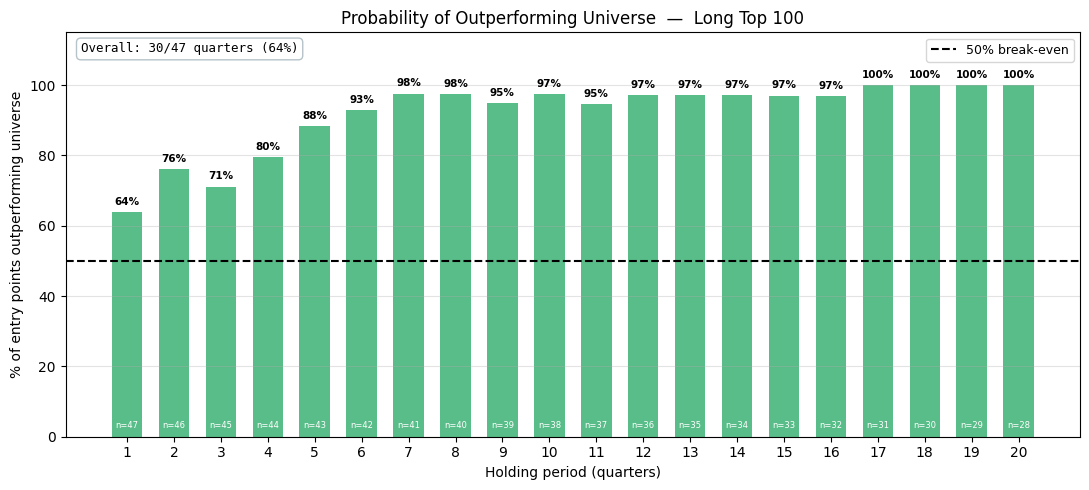

In [49]:
# ── Shared setup for the three holding-period charts ─────────────────────────

MAX_QUARTERS = 20

_merged = (
    pd.merge(port, bench, on="date", how="left")
    .dropna(subset=["long_return", "benchmark_return"])
    .reset_index(drop=True)
)
_n       = len(_merged)
_long_r  = _merged["long_return"].values
_bench_r = _merged["benchmark_return"].values
_rel_r   = _long_r / _bench_r

_xs     = list(range(1, min(MAX_QUARTERS, _n - 1) + 1))
_ns_obs = [_n - x + 1 for x in _xs]

# ── Graph 1: Probability of outperforming universe ────────────────────────────

probs = []
for x, n_obs in zip(_xs, _ns_obs):
    wins = sum(
        1 for t in range(n_obs)
        if np.prod(_long_r[t:t+x]) > np.prod(_bench_r[t:t+x])
    )
    probs.append(wins / n_obs * 100)

_n_better   = int(np.sum(_long_r > _bench_r))
_pct_better = _n_better / _n * 100

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(_xs, probs, width=0.65, alpha=0.85)
for bar, p in zip(bars, probs):
    bar.set_facecolor("#3BB273" if p >= 50 else "#E05252")

ax.axhline(50, color="black", lw=1.5, ls="--", label="50% break-even")
for x, p, n_o in zip(_xs, probs, _ns_obs):
    ax.text(x, p + 1.5, f"{p:.0f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
    ax.text(x, 2.0,     f"n={n_o}",  ha="center", va="bottom", fontsize=6.0, color="white")

ax.text(0.015, 0.975,
        f"Overall: {_n_better}/{_n} quarters ({_pct_better:.0f}%)",
        transform=ax.transAxes, fontsize=9, va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#B0BEC5", alpha=0.92))

ax.set_xlabel("Holding period (quarters)")
ax.set_ylabel("% of entry points outperforming universe")
ax.set_title(f"Probability of Outperforming Universe  —  Long Top {TOP_N}")
ax.set_ylim(0, 115)
ax.set_xticks(_xs)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


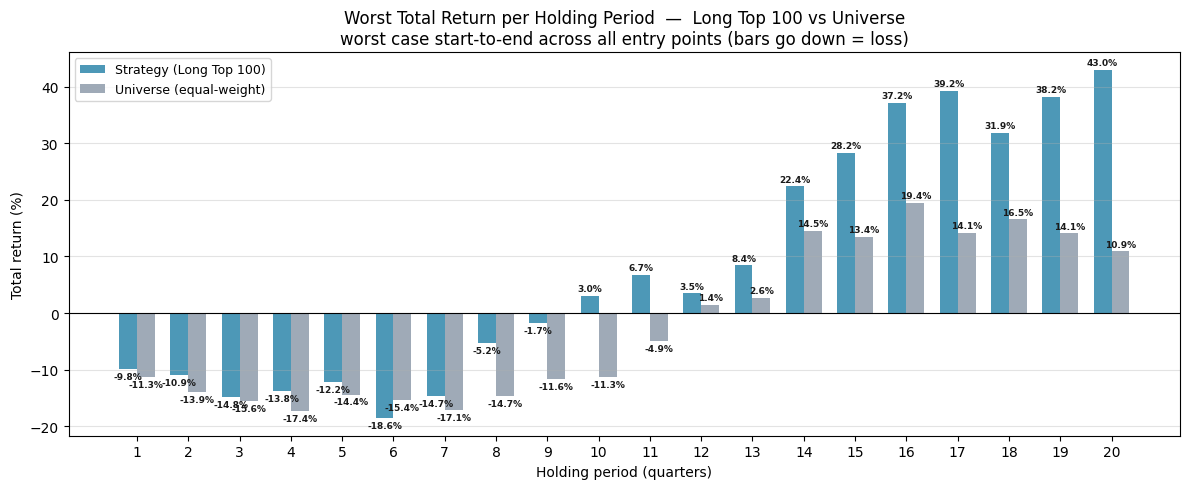

In [50]:
# ── Graph 2: Worst total return — Strategy vs Universe, per holding period ────
# For each entry point t and holding period x:
#   total return = cumprod(long_r[t:t+x]) - 1
# Each bar = worst (most negative) total return across all valid entry points for that x.

def _total_return(arr):
    return (np.prod(arr) - 1) * 100   # negative % if loss

worst_return_strategy = []
worst_return_universe = []

for x, n_obs in zip(_xs, _ns_obs):
    s_vals = [_total_return(_long_r[t:t+x])  for t in range(n_obs)]
    u_vals = [_total_return(_bench_r[t:t+x]) for t in range(n_obs)]
    worst_return_strategy.append(min(s_vals))
    worst_return_universe.append(min(u_vals))

x_arr = np.array(_xs)
w     = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_arr - w/2, worst_return_strategy, width=w, alpha=0.85,
       color="#2E86AB", label=f"Strategy (Long Top {TOP_N})")
ax.bar(x_arr + w/2, worst_return_universe, width=w, alpha=0.85,
       color="#8E9BAB", label="Universe (equal-weight)")

ax.axhline(0, color="black", lw=0.8)

for x, s, u in zip(x_arr, worst_return_strategy, worst_return_universe):
    for xpos, val in [(x - w/2, s), (x + w/2, u)]:
        ypos = val - 0.5 if val < 0 else val + 0.5
        va   = "top"     if val < 0 else "bottom"
        ax.text(xpos, ypos, f"{val:.1f}%", ha="center", va=va,
                fontsize=6.5, fontweight="bold", color="#1a1a1a")

ax.set_xlabel("Holding period (quarters)")
ax.set_ylabel("Total return (%)")
ax.set_title(
    f"Worst Total Return per Holding Period  —  Long Top {TOP_N} vs Universe\n"
    f"worst case start-to-end across all entry points (bars go down = loss)"
)
ax.set_xticks(_xs)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

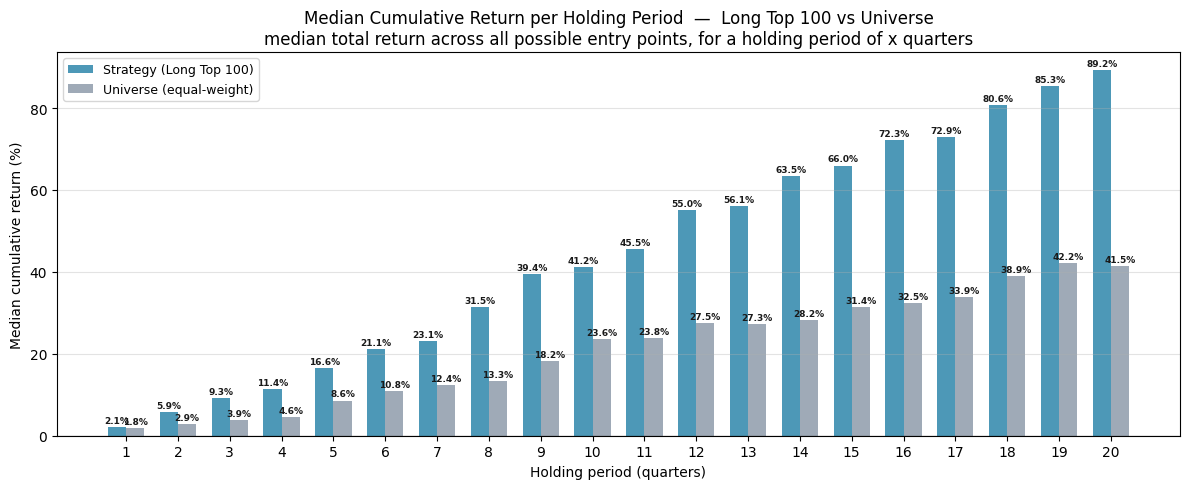

In [51]:
# ── Graph 3: Median cumulative return per holding period ──────────────────────
# For each entry point t and holding period x:
#   cumulative return = prod(r[t:t+x]) - 1
# Each bar = median across all valid entry points for that x.

median_return_strategy = []
median_return_universe = []

for x, n_obs in zip(_xs, _ns_obs):
    s_vals = [(np.prod(_long_r[t:t+x])  - 1) * 100 for t in range(n_obs)]
    u_vals = [(np.prod(_bench_r[t:t+x]) - 1) * 100 for t in range(n_obs)]
    median_return_strategy.append(np.median(s_vals))
    median_return_universe.append(np.median(u_vals))

x_arr = np.array(_xs)
w     = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_arr - w/2, median_return_strategy, width=w, alpha=0.85,
       color="#2E86AB", label=f"Strategy (Long Top {TOP_N})")
ax.bar(x_arr + w/2, median_return_universe, width=w, alpha=0.85,
       color="#8E9BAB", label="Universe (equal-weight)")

ax.axhline(0, color="black", lw=0.8)

for x, s, u in zip(x_arr, median_return_strategy, median_return_universe):
    for xpos, val in [(x - w/2, s), (x + w/2, u)]:
        ypos = val + 0.5 if val >= 0 else val - 0.5
        va   = "bottom" if val >= 0 else "top"
        ax.text(xpos, ypos, f"{val:.1f}%", ha="center", va=va,
                fontsize=6.5, fontweight="bold", color="#1a1a1a")

ax.set_xlabel("Holding period (quarters)")
ax.set_ylabel("Median cumulative return (%)")
ax.set_title(
    f"Median Cumulative Return per Holding Period  —  Long Top {TOP_N} vs Universe\n"
    f"median total return across all possible entry points, for a holding period of x quarters"
)
ax.set_xticks(_xs)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


In [ ]:
# ── Feature Importance: Top-3 features per period (time series) ───────────────
if fi_df is not None:
    top3_overall = (
        fi_df.groupby("feature")["importance"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )

    pivot = (
        fi_df[fi_df["feature"].isin(top3_overall)]
        .pivot_table(index="period_date", columns="feature", values="importance", aggfunc="sum")
        .fillna(0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#2E86AB", "#E8A838", "#3BB273"]
    for feat, color in zip(top3_overall, colors):
        if feat in pivot.columns:
            ax.plot(pivot.index, pivot[feat], label=feat, linewidth=1.8, color=color)

    ax.set_xlabel("Period date")
    ax.set_ylabel("Feature importance (gain)")
    ax.set_title(
        f"Top-3 Feature Importance Over Time  —  {PHASE} phase\n"
        f"gain importance per TSCV period"
    )
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance data not available.")

In [ ]:
# ── Feature Importance: Aggregated across all periods ────────────────────────
if fi_df is not None:
    agg = (
        fi_df.groupby("feature")["importance"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.barh(agg["feature"][::-1], agg["importance"][::-1], color="#2E86AB", alpha=0.85)
    for bar, val in zip(bars, agg["importance"][::-1]):
        ax.text(val + agg["importance"].max() * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f}", va="center", fontsize=8)
    ax.set_xlabel("Total gain importance (sum across all periods)")
    ax.set_title(
        f"Aggregated Feature Importance  —  {PHASE} phase\n"
        f"top 15 features by total gain across all TSCV periods"
    )
    ax.grid(axis="x", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance data not available.")